In [1]:
%cd ..
import os
import math
import cv2
import numpy as np
import paddle
import paddle.nn as nn
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import time

e:\code\git\PaddleSeg


In [2]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from mpl_toolkits.mplot3d import Axes3D

In [3]:
import paddleseg
from paddleseg.models import LiteMixFormer, HarDNet
from paddleseg.models import PPLiteSeg,BiSeNetV2, VisionTransformer, SegFormer
from paddleseg.models.backbones import STDC1, MixVisionTransformer_B0, ViT_small_patch16_224
paddle.set_device('cpu')

Place(cpu)

In [4]:
model = paddleseg.models.aMulMini2xDetail.MulSegMini2xDetail(2)
_pre_path = r'C:\Users\hp\Desktop\model.pdparams'
_load_layer_state_dict = paddle.load(_pre_path)
model.set_dict(_load_layer_state_dict)

In [5]:
img = np.array(Image.open(r'C:\Users\hp\Desktop\tc_data\150x70\rust\imgs\81.jpg'))
img = np.transpose(img, [2, 0,1])
img = img[np.newaxis, ...]
img_tensor = paddle.to_tensor(img.astype(np.float32)/255.0)

In [6]:
model.eval()
result = model(img_tensor)
# model.
print(result[0][0][1].max(), result[0][0][1].min())

Tensor(shape=[1], dtype=float32, place=Place(cpu), stop_gradient=False,
       [9.00031376]) Tensor(shape=[1], dtype=float32, place=Place(cpu), stop_gradient=False,
       [-24.60835457])


In [7]:
front = result[0][0][1]
front = front.numpy()

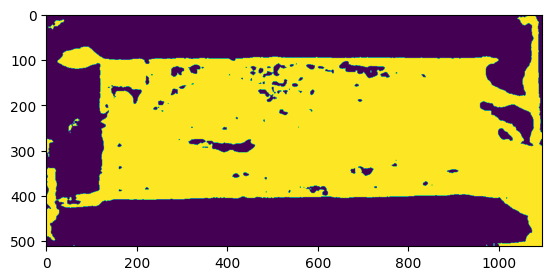

In [9]:
plt.imshow(front>0.5)

In [45]:
cv2.imwrite(r'C:\Users\hp\Desktop\1.tiff',front)

True

28.134546


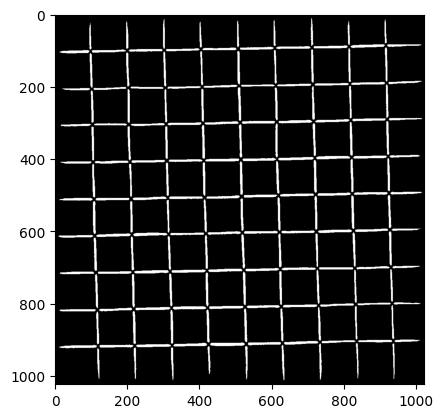

In [44]:
plt.imshow(front>10, cmap='gray')
print(front.max())

C:\Users\hp\AppData\Local\Temp\ipykernel_13276\610538576.py:2: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


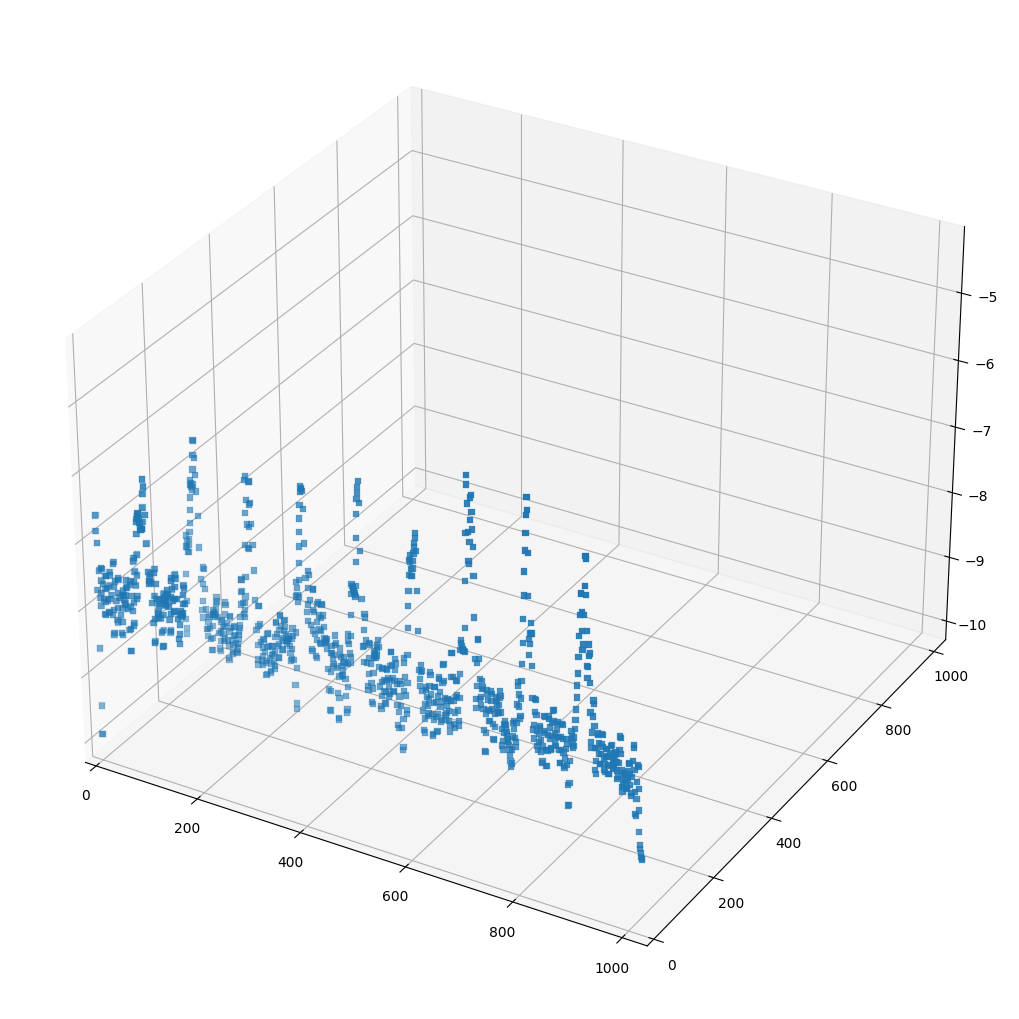

In [58]:
fig = plt.figure(figsize=(10,10))
ax = Axes3D(fig)

X = np.arange(0, 1024, 1)
Y = np.arange(0, 1024, 1)
X, Y = np.meshgrid(X, Y)
Z = front
# Z[front>0] = 0
# surf = subplot.plot_surface(X, Y, Z, cmap='hot',
#                        linewidth=0, antialiased=False)

X = X.ravel()
Y = Y.ravel()
Z = Z.ravel()

ax.set_xlim(0, 1024)
ax.set_ylim(0, 1024)
ax.scatter(X[:1200], Y[:1200], Z[:1200], marker=',',linewidths=0.2)
# fig.colorbar(surf, shrink=0.5, aspect=5)